# Wikipedia Election Polls — Web Scraping with Beautiful Soup

This notebook scrapes the **2024 US Presidential Election** polling data from Wikipedia and performs descriptive analyses.

**Techniques covered:**
- `requests` + `BeautifulSoup` — fetching and navigating HTML
- `find()` / `find_all()` — locating specific tags and CSS classes
- `pd.read_html()` — converting HTML tables to DataFrames
- `matplotlib` — visualisations using the project house style

**Source:** [Wikipedia – Nationwide opinion polling for the 2024 United States presidential election](https://en.wikipedia.org/wiki/Nationwide_opinion_polling_for_the_2024_United_States_presidential_election)

## 0. Setup

In [129]:
import sys, os, re, warnings
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))
warnings.filterwarnings('ignore')

import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from house_style import (
    apply_style, styled_fig, style_ax,
    REPUBLICAN, DEMOCRAT, TEXT_PRIMARY, TEXT_MUTED,
    BG_DARK, BG_PANEL, GRID_COLOR, PALETTE
)
apply_style()
print('Setup complete.')

Setup complete.


## 1. Scraping with Beautiful Soup

### 1.1 Fetch the page

In [130]:
URL = ('https://en.wikipedia.org/wiki/'
       'Nationwide_opinion_polling_for_the_2024_United_States_presidential_election')

headers = {'User-Agent': 'Mozilla/5.0 (compatible; SMWA-project/1.0)'}
response = requests.get(URL, headers=headers, timeout=20)
response.raise_for_status()

print('Status :', response.status_code)
print('Size   :', f'{len(response.text):,}', 'characters')

Status : 200
Size   : 1,591,790 characters


### 1.2 Parse HTML structure with BeautifulSoup

In [131]:
# Build the BeautifulSoup object
soup = BeautifulSoup(response.text, 'html.parser')

# find() — first match only
print('Page title:', soup.find('h1', id='firstHeading').get_text())

# find_all() — all section headings
print('\nSections on the page:')
for h in soup.find_all(['h2', 'h3'])[:12]:
    print(' •', h.get_text(strip=True))

# find_all() — count wikitables
all_tables = soup.find_all('table', class_='wikitable')
print(f'\nTotal wikitables: {len(all_tables)}')

Page title: Nationwide opinion polling for the 2024 United States presidential election

Sections on the page:
 • Contents
 • Polling aggregation
 • Kamala Harris vs. Donald Trump
 • Kamala Harris vs. Donald Trump vs. Robert F. Kennedy Jr. vs. Jill Stein vs. Chase Oliver vs. Cornel West
 • National poll results
 • Kamala Harris vs. Donald Trump
 • Kamala Harris vs. Donald Trump vs. Robert F. Kennedy Jr. vs. Cornel West vs. Jill Stein
 • Hypothetical polling
 • Robert F. Kennedy Jr.
 • Joe Biden vs. Donald Trump
 • Undeclared and generic candidates
 • Limitations

Total wikitables: 79


### 1.3 Load all tables and select the polling data

We use `pd.read_html()` to parse every table on the page, then keep the ones that have both candidate names in their columns.

In [132]:
# ── Use BeautifulSoup to locate the correct tables ────────────────────────────

# find_all() — get every wikitable on the page
all_tables = soup.find_all('table', class_='wikitable')
print(f'Total wikitables on page: {len(all_tables)}')

def col_text(table):
    """Return all header text of a table as a single lowercase string."""
    return ' '.join(th.get_text(strip=True) for th in table.find_all('th')).lower()

# Keep only tables whose headers mention both candidates and have enough data rows
poll_tables = [
    t for t in all_tables
    if 'trump' in col_text(t)
    and ('harris' in col_text(t) or 'kamala' in col_text(t))
    and len(t.find_all('tr')) > 10          # skip tiny summary tables
]
print(f'Polling tables selected : {len(poll_tables)}')

# ── Convert each BS4 table element to a DataFrame via pd.read_html ─────────────
raw_parts = []
for t in poll_tables:
    dfs = pd.read_html(str(t))          # str(t) gives the raw HTML of that table
    for d in dfs:
        # Flatten MultiIndex columns (Wikipedia uses rowspan/colspan headers)
        if isinstance(d.columns, pd.MultiIndex):
            d.columns = [
                ' '.join(str(x) for x in col if str(x) != 'nan').strip()
                for col in d.columns
            ]
        raw_parts.append(d)

df_raw = pd.concat(raw_parts, ignore_index=True)
print(f'Raw shape: {df_raw.shape}')

Total wikitables on page: 79
Polling tables selected : 6
Raw shape: (342, 11)


## 2. Data Cleaning

In [133]:
# Concatenate all polling tables
df_raw = pd.concat(poll_dfs, ignore_index=True)

# Flatten MultiIndex columns
if isinstance(df_raw.columns, pd.MultiIndex):
    df_raw.columns = [
        ' '.join(str(x) for x in c if str(x) != 'nan').strip()
        for c in df_raw.columns
    ]

print('Raw columns:')
for c in df_raw.columns:
    sample = df_raw[c].dropna().astype(str).unique()[:2].tolist()
    print(f'  {c!r}  ->  {sample}')

Raw columns:
  'Poll source'  ->  ['Zogby[9]', 'Research Co.[10]']
  'Date'  ->  ['November 2–3, 2024', 'November 1–3, 2024']
  'Sample size[c]'  ->  ['1,005 (LV)', '1,003 (LV)']
  'Margin of error'  ->  ['±\xa03.2%', '±\xa03.1%']
  'Kamala Harris Democratic'  ->  ['49%', '48%']
  'Donald Trump Republican'  ->  ['46%', '48%']
  'Others/ Undecided'  ->  ['5%', '6%']
  'Lead'  ->  ['3%', '2%']
  'Robert F. Kennedy Jr. Independent'  ->  ['—N/a', '2%']
  'Cornel West Independent'  ->  ['0.8%', '0.7%']
  'Jill Stein Green'  ->  ['0.5%', '0.7%']


In [134]:
# Rename columns based on what we see above
rename = {}
for col in df_raw.columns:
    low = col.lower()
    if ('trump' in low or 'republican' in low) and 'harris' not in low and 'democrat' not in low:
        rename[col] = 'Trump'
    elif 'harris' in low or 'kamala' in low or 'democrat' in low:
        rename[col] = 'Harris'
    elif ('poll' in low or 'source' in low or 'firm' in low) and 'date' not in low:
        rename[col] = 'Pollster'
    elif 'date' in low or 'field' in low:
        rename[col] = 'Date'
    elif 'sample' in low or low.startswith('n '):
        rename[col] = 'SampleSize'
    elif ('lead' in low or 'margin' in low) and 'error' not in low:
        rename[col] = 'Margin'

df = df_raw.rename(columns=rename)

# Drop duplicate column names
df = df.loc[:, ~df.columns.duplicated(keep='first')]

# Keep only useful columns
keep = [c for c in ['Pollster', 'Date', 'SampleSize', 'Trump', 'Harris', 'Margin']
        if c in df.columns]
df = df[keep]

print('Renamed columns:', df.columns.tolist())
df.head(5)

Renamed columns: ['Pollster', 'Date', 'SampleSize', 'Trump', 'Harris', 'Margin']


,Pollster,Date,SampleSize,Trump,Harris,Margin
0,Zogby[9],"November 2–3, 2024","1,005 (LV)",46%,49%,3%
1,Research Co.[10],"November 2–3, 2024","1,003 (LV)",46%,48%,2%
2,Reuters/Ipsos[11],"November 1–3, 2024",973 (LV),48%,50%,2%
3,TIPP[12],"November 1–3, 2024","1,411 (LV)",48%,48%,—N/a
4,Patriot Polling[13],"November 1–3, 2024",1115 (RV),48%,49%,1%


In [135]:
# ── Parse percentages ─────────────────────────────────────────────────────────
for col in ['Trump', 'Harris', 'Margin']:
    if col in df.columns:
        df[col] = (
            df[col].astype(str)
                   .str.replace('%', '', regex=False)
                   .str.replace('[^0-9.\-]', '', regex=True)
                   .pipe(pd.to_numeric, errors='coerce')
        )

# ── Parse dates ───────────────────────────────────────────────────────────────
if 'Date' in df.columns:
    def parse_date(s):
        s = re.sub(r'\[.*?\]', '', str(s)).strip()   # strip footnotes
        # Date ranges like "Oct 1\u20135, 2024" -> take the end part
        for sep in ['\u2013', '\u2014', '\u2012']:
            if sep in s:
                left, right = s.split(sep, 1)
                right = right.strip()
                if not re.search(r'[A-Za-z]', right.split(',')[0]):
                    month = re.match(r'[A-Za-z]+', left.strip())
                    if month:
                        right = month.group() + ' ' + right
                s = right
                break
        try:
            return pd.to_datetime(s.strip())
        except Exception:
            return pd.NaT

    df['Date'] = df['Date'].apply(parse_date)

# ── Keep only 2024 ────────────────────────────────────────────────────────────
if 'Date' in df.columns:
    df = df[df['Date'].dt.year == 2024]

# ── Drop rows with no poll numbers ────────────────────────────────────────────
cands = [c for c in ['Trump', 'Harris'] if c in df.columns]
df = df.dropna(subset=cands, how='all').reset_index(drop=True)
df = df.sort_values('Date').reset_index(drop=True)

if 'Margin' not in df.columns:
    df['Margin'] = df['Trump'] - df['Harris']

print(f'Polls loaded  : {len(df)}')
print(f'Date range    : {df["Date"].min().date()} -> {df["Date"].max().date()}')
print(f'Trump range   : {df["Trump"].min():.1f} – {df["Trump"].max():.1f}%')
print(f'Harris range  : {df["Harris"].min():.1f} – {df["Harris"].max():.1f}%')
df.head(8)

Polls loaded  : 256
Date range    : 2024-06-24 -> 2024-11-04
Trump range   : 37.0 – 53.0%
Harris range  : 38.0 – 53.0%


,Pollster,Date,SampleSize,Trump,Harris,Margin
0,McLaughlin & Associates[206],2024-06-24,"1,000 (LV)",47.0,42.0,5.0
1,Forbes/HarrisX[204],2024-06-30,"1,500 (RV)",53.0,47.0,6.0
2,CNN/SSRS[205],2024-06-30,"1,045 (RV)",47.0,45.0,2.0
3,Forbes/HarrisX[204],2024-06-30,"1,500 (RV)",43.0,38.0,NaN
4,Forbes/HarrisX[204],2024-06-30,"1,500 (RV)",43.0,40.0,NaN
5,Yahoo News/YouGov[203],2024-07-01,"1,176 (RV)",47.0,45.0,2.0
6,Reuters/Ipsos[202],2024-07-02,"1,070 (A)",43.0,42.0,1.0
7,Bendixen & Amandi International (D)[201],2024-07-06,"1,000 (LV)",41.0,42.0,1.0


## 3. Analysis & Visualisations

### 3.1 Polling averages over time (7-day rolling average)

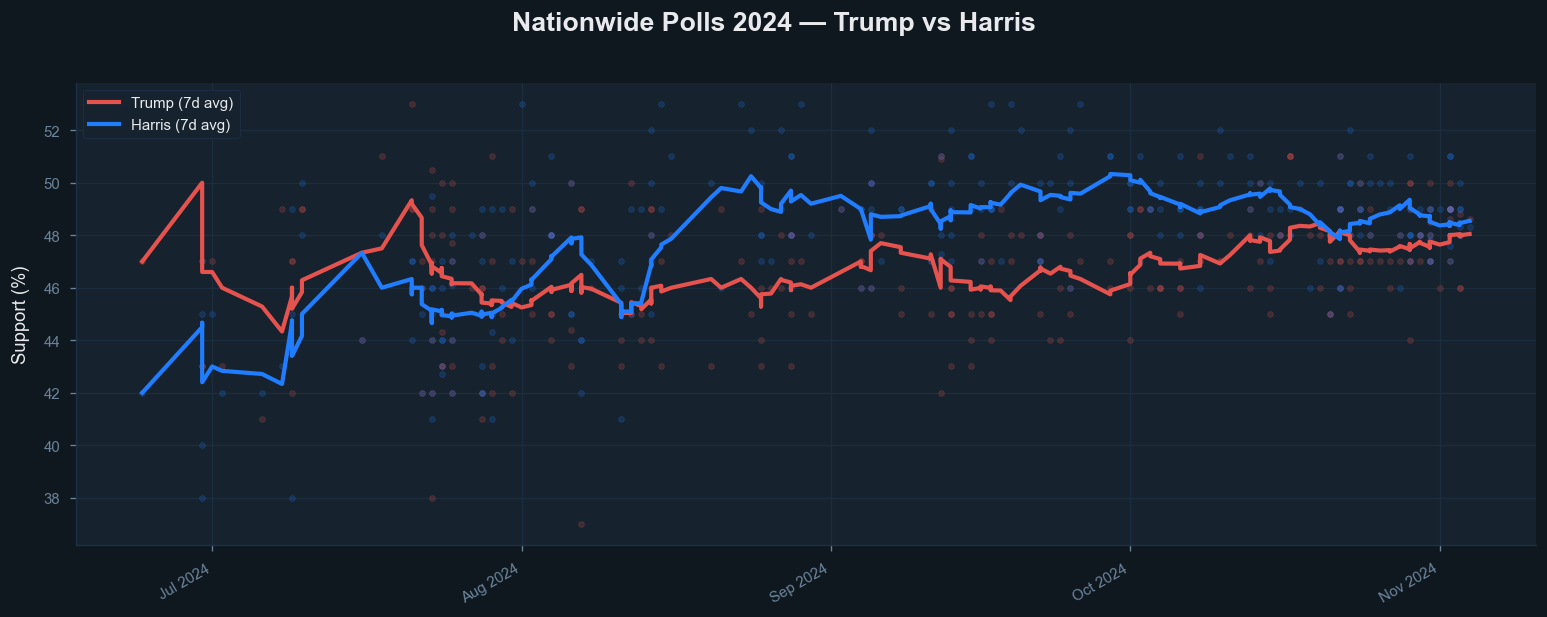

In [136]:
df_plot = df.dropna(subset=['Date', 'Trump', 'Harris']).set_index('Date').sort_index()

trump_roll  = df_plot['Trump'].rolling('7D',  min_periods=1).mean()
harris_roll = df_plot['Harris'].rolling('7D', min_periods=1).mean()

fig, ax = styled_fig(figsize=(13, 5), title='Nationwide Polls 2024 — Trump vs Harris')

ax.scatter(df_plot.index, df_plot['Trump'],  color=REPUBLICAN, alpha=0.2, s=12, zorder=2)
ax.scatter(df_plot.index, df_plot['Harris'], color=DEMOCRAT,   alpha=0.2, s=12, zorder=2)
ax.plot(trump_roll,  color=REPUBLICAN, linewidth=2.5, label='Trump (7d avg)',  zorder=3)
ax.plot(harris_roll, color=DEMOCRAT,   linewidth=2.5, label='Harris (7d avg)', zorder=3)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
style_ax(ax, ylabel='Support (%)', grid_axis='y')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

### 3.2 Trump–Harris margin over time

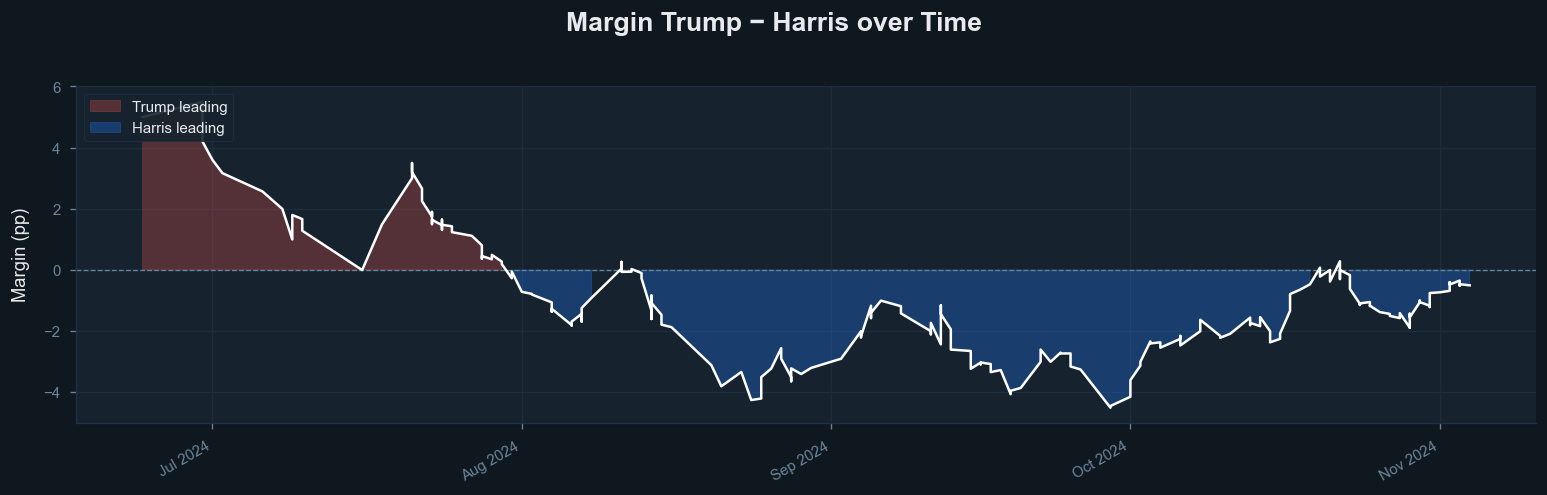

In [137]:
margin_roll = trump_roll - harris_roll

fig, ax = styled_fig(figsize=(13, 4), title='Margin Trump − Harris over Time')
ax.fill_between(margin_roll.index, margin_roll, 0,
                where=(margin_roll >= 0), color=REPUBLICAN, alpha=0.3, label='Trump leading')
ax.fill_between(margin_roll.index, margin_roll, 0,
                where=(margin_roll <  0), color=DEMOCRAT,   alpha=0.3, label='Harris leading')
ax.plot(margin_roll, color='white', linewidth=1.5, zorder=3)
ax.axhline(0, color=TEXT_MUTED, linewidth=0.8, linestyle='--')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
style_ax(ax, ylabel='Margin (pp)', grid_axis='y')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

### 3.3 Distribution of poll percentages

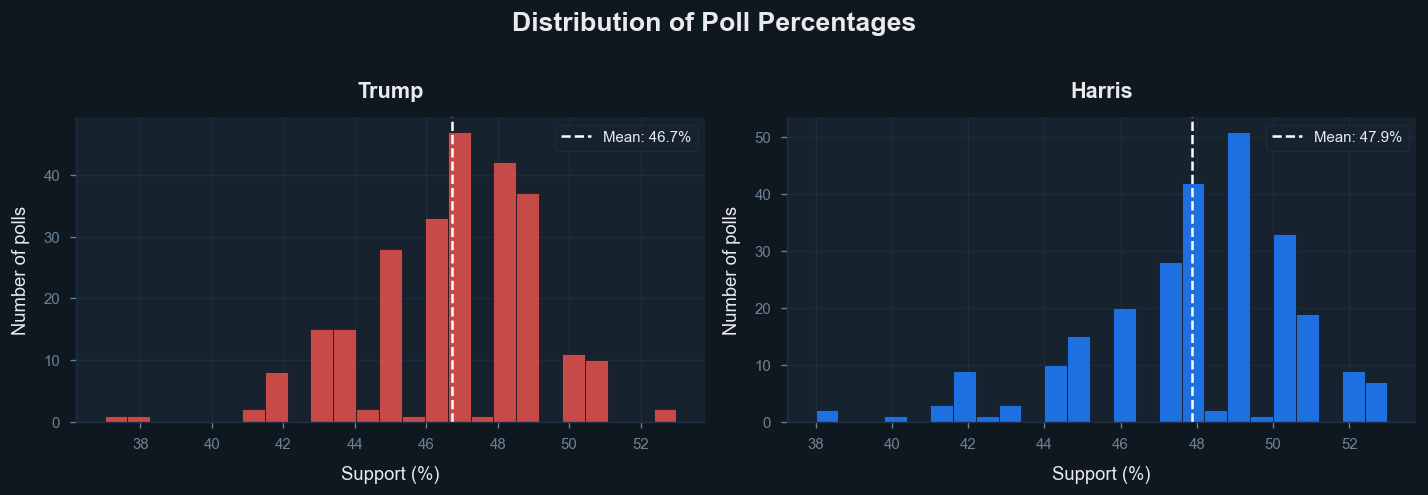

In [138]:
fig, axes = styled_fig(nrows=1, ncols=2, figsize=(12, 4), title='Distribution of Poll Percentages')

for ax, col, color in zip(axes, ['Trump', 'Harris'], [REPUBLICAN, DEMOCRAT]):
    data = df_plot[col].dropna()
    ax.hist(data, bins=25, color=color, alpha=0.85, edgecolor=BG_DARK)
    ax.axvline(data.mean(), color='white', linestyle='--', linewidth=1.5,
               label=f'Mean: {data.mean():.1f}%')
    style_ax(ax, xlabel='Support (%)', ylabel='Number of polls', title=col, grid_axis='y')
    ax.legend()

plt.tight_layout()
plt.show()

### 3.4 Monthly averages — grouped bar chart

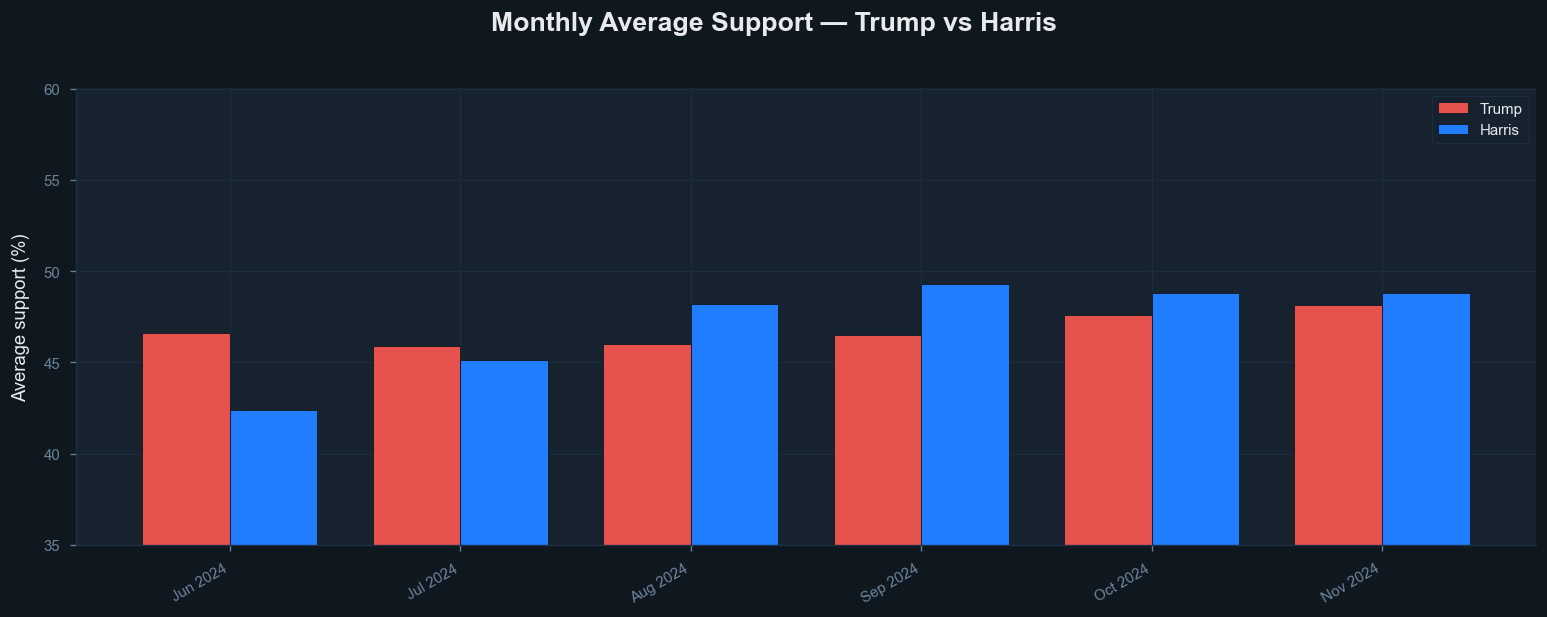

In [139]:
df_monthly = df_plot[['Trump', 'Harris']].resample('ME').mean().dropna()
labels = df_monthly.index.strftime('%b %Y')
x, w = np.arange(len(labels)), 0.38

fig, ax = styled_fig(figsize=(13, 5), title='Monthly Average Support — Trump vs Harris')
ax.bar(x - w/2, df_monthly['Trump'],  w, color=REPUBLICAN, label='Trump',  edgecolor=BG_DARK)
ax.bar(x + w/2, df_monthly['Harris'], w, color=DEMOCRAT,   label='Harris', edgecolor=BG_DARK)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha='right', color=TEXT_MUTED)
ax.set_ylim(35, 60)
style_ax(ax, ylabel='Average support (%)', grid_axis='y')
ax.legend()
plt.tight_layout()
plt.show()

### 3.5 Top pollsters — average margin

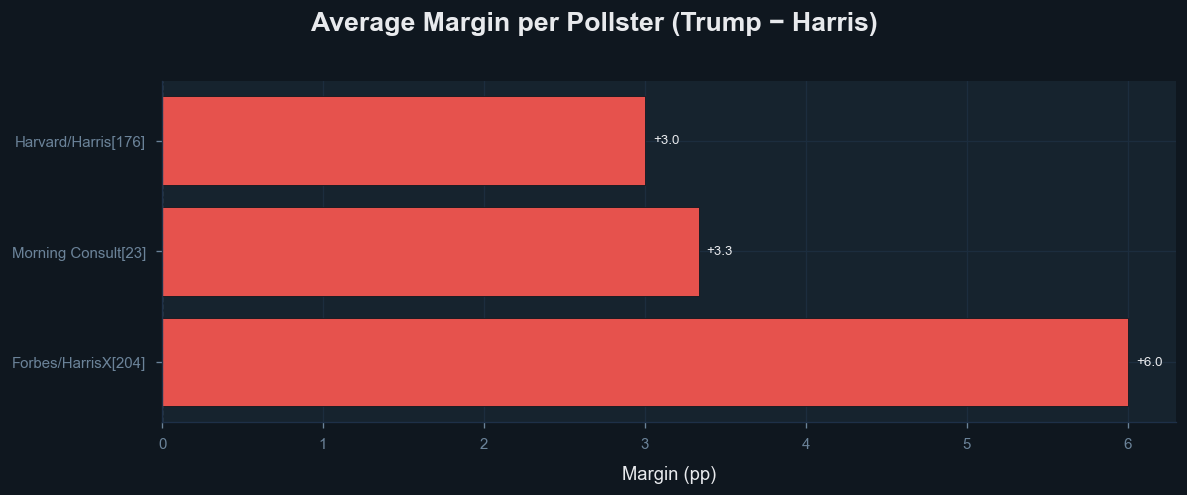

In [140]:
if 'Pollster' in df.columns:
    counts = df['Pollster'].value_counts()
    top = counts[counts >= 3].index
    stats = (
        df[df['Pollster'].isin(top)]
        .groupby('Pollster')[['Trump', 'Harris', 'Margin']]
        .mean()
        .sort_values('Margin', ascending=False)
    )
    colors = [REPUBLICAN if m >= 0 else DEMOCRAT for m in stats['Margin']]
    fig, ax = styled_fig(figsize=(10, max(4, len(stats) * 0.4)),
                         title='Average Margin per Pollster (Trump − Harris)')
    bars = ax.barh(stats.index, stats['Margin'], color=colors, edgecolor=BG_DARK)
    ax.axvline(0, color=TEXT_MUTED, linewidth=0.8, linestyle='--')
    for bar, val in zip(bars, stats['Margin']):
        xpos = val + 0.05 if val >= 0 else val - 0.05
        ax.text(xpos, bar.get_y() + bar.get_height()/2,
                f'{val:+.1f}', va='center', ha='left' if val >= 0 else 'right',
                color=TEXT_PRIMARY, fontsize=8)
    style_ax(ax, xlabel='Margin (pp)', grid_axis='x')
    plt.tight_layout()
    plt.show()
else:
    print('No Pollster column available.')

## 4. Summary

In [141]:
print('=' * 45)
print('  SUMMARY — WIKIPEDIA POLLS 2024')
print('=' * 45)
print(f'  Polls analysed           : {len(df)}')
print(f'  Average Trump support    : {df["Trump"].mean():.2f}%')
print(f'  Average Harris support   : {df["Harris"].mean():.2f}%')
print(f'  Average margin (T - H)   : {df["Margin"].mean():+.2f} pp')
print(f'  Polls Trump leading      : {(df["Margin"] > 0).sum()}')
print(f'  Polls Harris leading     : {(df["Margin"] < 0).sum()}')
print('=' * 45)

  SUMMARY — WIKIPEDIA POLLS 2024
  Polls analysed           : 256
  Average Trump support    : 46.72%
  Average Harris support   : 47.89%
  Average margin (T - H)   : +3.07 pp
  Polls Trump leading      : 192
  Polls Harris leading     : 0
